### Exploratory Data Analysis (EDA)

In [79]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import seaborn as sns
sns.set()

In [80]:
df= pd.read_csv('Data/featured_eng_data.csv')

In [81]:
df.head

<bound method NDFrame.head of               Brand    Price       Body  Mileage  EngineV Engine Type  \
0               BMW   4200.0      sedan      277      2.0      Petrol   
1     Mercedes-Benz   7900.0        van      427      2.9      Diesel   
2     Mercedes-Benz  13300.0      sedan      358      5.0         Gas   
3              Audi  23000.0  crossover      240      4.2      Petrol   
4            Toyota  18300.0  crossover      120      2.0      Petrol   
...             ...      ...        ...      ...      ...         ...   
3811        Renault   6800.0      sedan      152      1.6      Petrol   
3812     Volkswagen  11500.0        van      163      2.5      Diesel   
3813         Toyota  17900.0      sedan       35      1.6      Petrol   
3814            BMW   6500.0      sedan        1      3.5      Petrol   
3815     Volkswagen  13500.0        van      124      2.0      Diesel   

     Registration  Year              Model  Car_Age  Mileage_per_Year  \
0             yes  1

In [82]:
print("Data shape:", df.shape)
print("\nData types:\n", df.dtypes)

Data shape: (3816, 14)

Data types:
 Brand                          object
Price                         float64
Body                           object
Mileage                         int64
EngineV                       float64
Engine Type                    object
Registration                   object
Year                            int64
Model                          object
Car_Age                         int64
Mileage_per_Year              float64
log_price                     float64
is_luxury                       int64
Luxury_EngineV_Interaction    float64
dtype: object


In [83]:
print("\nDescriptive Statistics:")
display(df.describe().T)


Descriptive Statistics:


,count,mean,std,min,25%,50%,75%,max
Price,3816.0,17708.599610,18262.379077,800.000000,7191.750000,11500.000000,21000.000000,124999.000000
Mileage,3816.0,161.829140,95.257431,0.000000,93.000000,158.000000,228.000000,435.000000
EngineV,3816.0,2.447031,0.948768,0.600000,1.800000,2.200000,3.000000,6.300000
Year,3816.0,2006.619759,6.087334,1988.000000,2003.000000,2008.000000,2011.000000,2016.000000
Car_Age,3816.0,18.380241,6.087334,9.000000,14.000000,17.000000,22.000000,37.000000
Mileage_per_Year,3816.0,8.381088,3.995107,0.000000,6.000000,8.700000,11.120000,22.710000
log_price,3816.0,9.398958,0.866397,6.684612,8.880688,9.350102,9.952278,11.736061
is_luxury,3816.0,0.459644,0.498434,0.000000,0.000000,0.000000,1.000000,1.000000
Luxury_EngineV_Interaction,3816.0,1.297822,1.562701,0.000000,0.000000,0.000000,2.500000,6.300000


In [84]:
df = df.drop(columns=['Price'])


In [85]:

from statsmodels.stats.outliers_influence import variance_inflation_factor

variables = df[['Mileage','Year','EngineV']]

vif = pd.DataFrame()

vif["VIF"] = [variance_inflation_factor(variables.values, i) for i in range(variables.shape[1])]

vif["Features"] = variables.columns

vif

,VIF,Features
0,3.859718,Mileage
1,10.358336,Year
2,7.652842,EngineV


In [86]:
# as we have Car_Age already we dont need year, removing it will help us avoid multicollinearity with such high VIF.
df = df.drop(columns=['Year'])

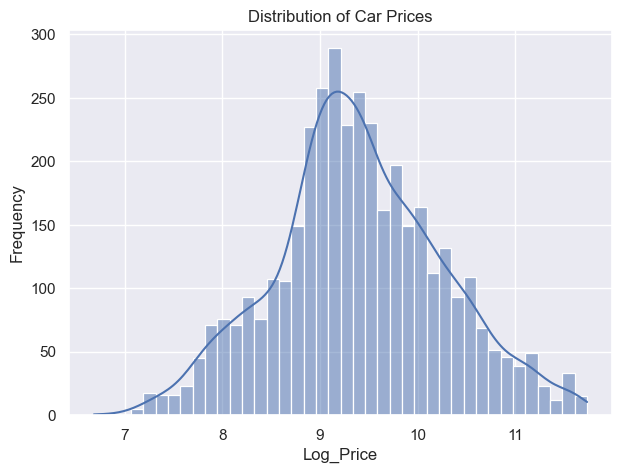

In [87]:
plt.figure(figsize=(7,5))
sns.histplot(df['log_price'], bins=40, kde=True)
plt.title('Distribution of Car Prices')
plt.xlabel('Log_Price')
plt.ylabel('Frequency')
plt.savefig('Visuals/Distribution of Car Prices.png')
plt.show()

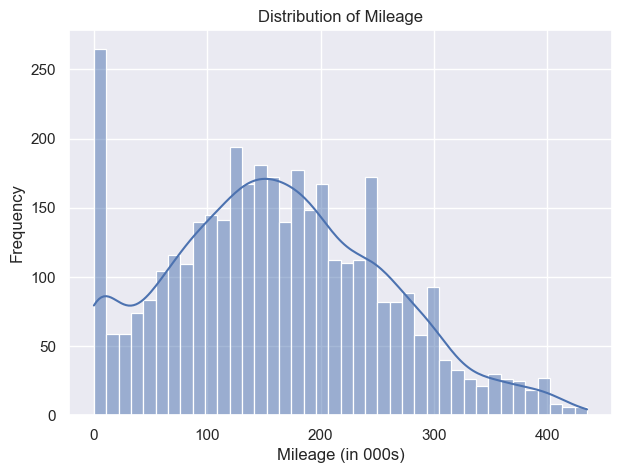

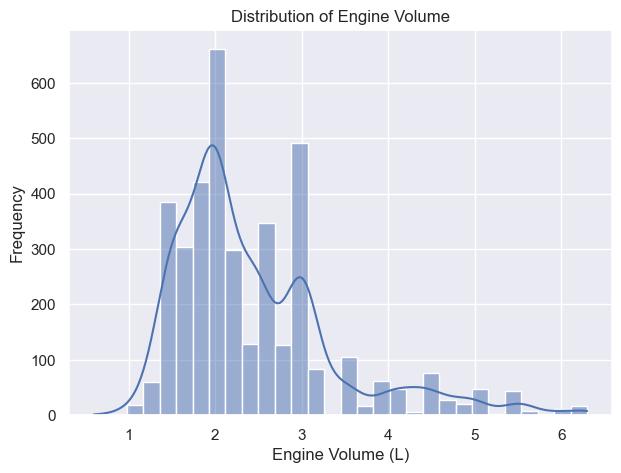

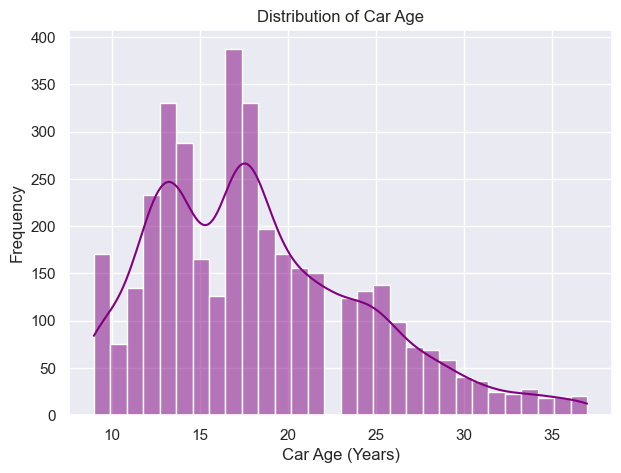

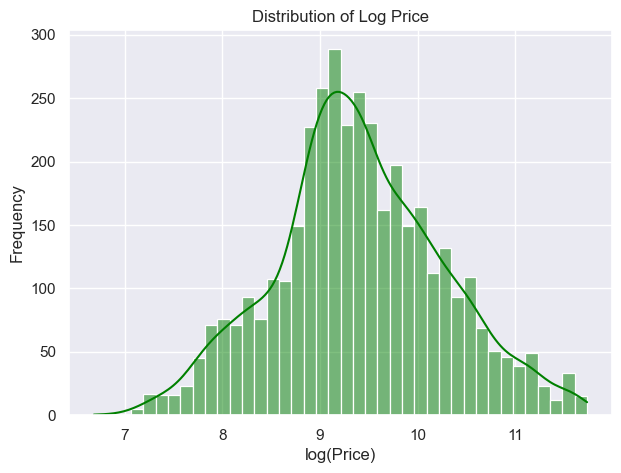

In [88]:


#  Mileage distribution
plt.figure(figsize=(7,5))
sns.histplot(df['Mileage'], bins=40, kde=True)
plt.title('Distribution of Mileage')
plt.xlabel('Mileage (in 000s)')
plt.ylabel('Frequency')
plt.savefig('Visuals/Distribution of Mileage.png')
plt.show()

#  Engine Volume distribution
plt.figure(figsize=(7,5))
sns.histplot(df['EngineV'], bins=30, kde=True)
plt.title('Distribution of Engine Volume')
plt.xlabel('Engine Volume (L)')
plt.ylabel('Frequency')
plt.savefig('Visuals/Distribution of Engine Volume.png')
plt.show()

# Car Age distribution
plt.figure(figsize=(7,5))
sns.histplot(df['Car_Age'], bins=30, kde=True, color='purple')
plt.title('Distribution of Car Age')
plt.xlabel('Car Age (Years)')
plt.ylabel('Frequency')
plt.savefig('Visuals/Distribution of Car Age.png')
plt.show()

# log_price
if 'log_price' in df.columns:
    plt.figure(figsize=(7,5))
    sns.histplot(df['log_price'], bins=40, kde=True, color='green')
    plt.title('Distribution of Log Price')
    plt.xlabel('log(Price)')
    plt.ylabel('Frequency')
    plt.savefig('Visuals/Distribution of Log Price.png')
    plt.show()


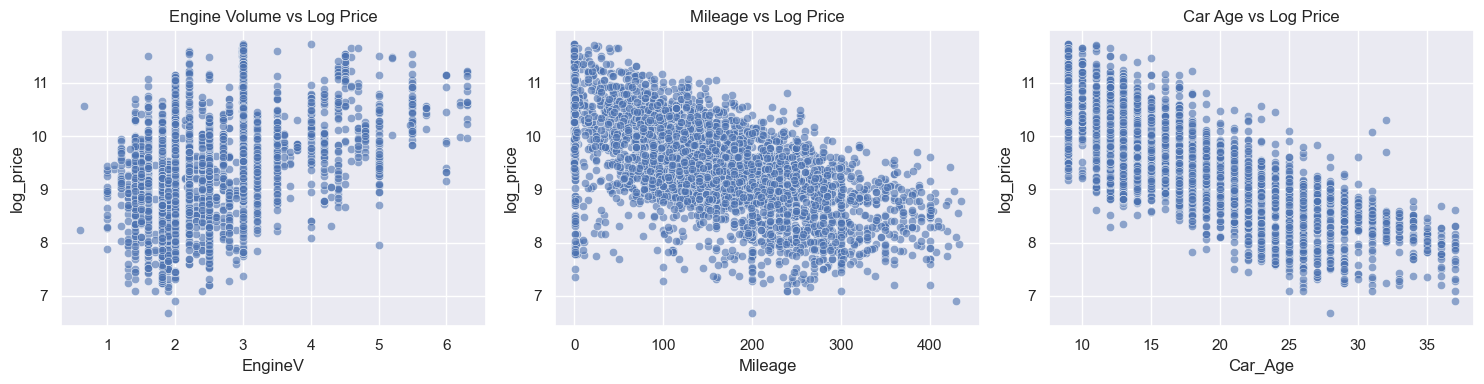

In [89]:
plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
sns.scatterplot(data=df, x='EngineV', y='log_price', alpha=0.6)
plt.title('Engine Volume vs Log Price')

plt.subplot(1,3,2)
sns.scatterplot(data=df, x='Mileage', y='log_price', alpha=0.6)
plt.title('Mileage vs Log Price')

plt.subplot(1,3,3)
sns.scatterplot(data=df, x='Car_Age', y='log_price', alpha=0.6)
plt.title('Car Age vs Log Price')

plt.tight_layout()
plt.savefig('Visuals/EngineV_Mileage_Car_Age vs Log_Price.png(Scatterplot).png')
plt.show()



In [90]:
df.dtypes

Brand                          object
Body                           object
Mileage                         int64
EngineV                       float64
Engine Type                    object
Registration                   object
Model                          object
Car_Age                         int64
Mileage_per_Year              float64
log_price                     float64
is_luxury                       int64
Luxury_EngineV_Interaction    float64
dtype: object

In [91]:
df.describe()

,Mileage,EngineV,Car_Age,Mileage_per_Year,log_price,is_luxury,Luxury_EngineV_Interaction
count,3816.000000,3816.000000,3816.000000,3816.000000,3816.000000,3816.000000,3816.000000
mean,161.829140,2.447031,18.380241,8.381088,9.398958,0.459644,1.297822
std,95.257431,0.948768,6.087334,3.995107,0.866397,0.498434,1.562701
min,0.000000,0.600000,9.000000,0.000000,6.684612,0.000000,0.000000
25%,93.000000,1.800000,14.000000,6.000000,8.880688,0.000000,0.000000
50%,158.000000,2.200000,17.000000,8.700000,9.350102,0.000000,0.000000
75%,228.000000,3.000000,22.000000,11.120000,9.952278,1.000000,2.500000
max,435.000000,6.300000,37.000000,22.710000,11.736061,1.000000,6.300000


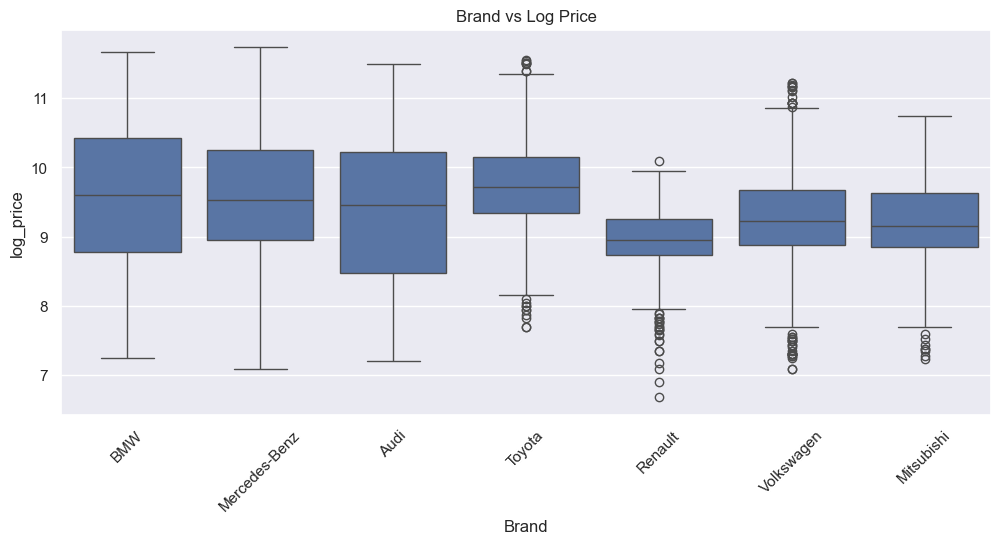

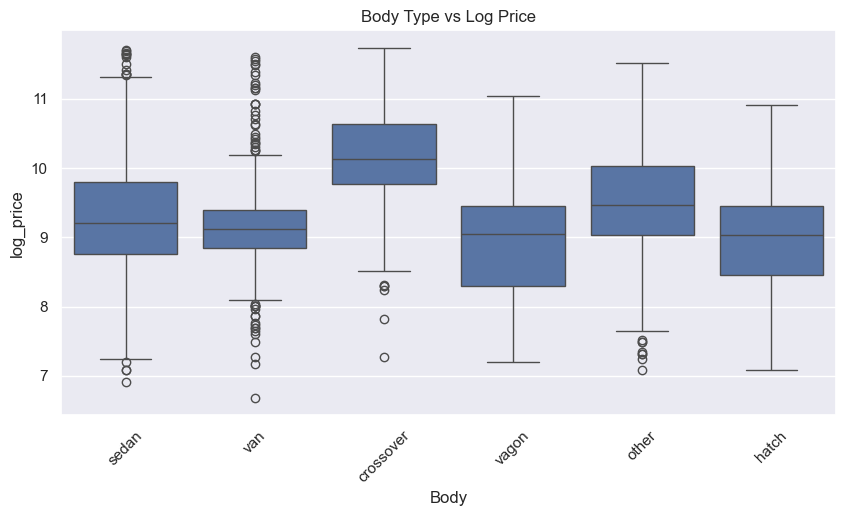

In [92]:
# Boxplot: Brand vs Log Price
plt.figure(figsize=(12, 5))
sns.boxplot(data=df, x='Brand', y='log_price')
plt.title('Brand vs Log Price')
plt.xticks(rotation=45)
plt.savefig('Visuals/Brand vs Log Price(Boxplot).png')
plt.show()

# Boxplot: Body Type vs Log Price
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='Body', y='log_price')
plt.title('Body Type vs Log Price')
plt.xticks(rotation=45)
plt.savefig('Visuals/Body Type vs Log Price.png')
plt.show()


Interaction_Premium_Validation.png

DataFrame head after feature engineering:
           Brand       Body  Mileage  EngineV Engine Type Registration  \
0            BMW      sedan      277      2.0      Petrol          yes   
1  Mercedes-Benz        van      427      2.9      Diesel          yes   
2  Mercedes-Benz      sedan      358      5.0         Gas          yes   
3           Audi  crossover      240      4.2      Petrol          yes   
4         Toyota  crossover      120      2.0      Petrol          yes   

          Model  Car_Age  Mileage_per_Year  log_price  is_luxury  \
0           320       34              8.15   8.342840          1   
1  Sprinter 212       26             16.42   8.974618          1   
2         S 500       22             16.27   9.495519          1   
3            Q7       18             13.33  10.043249          1   
4         Rav 4       14              8.57   9.814656          0   

   Luxury_EngineV_Interaction  
0                         2.0  
1   

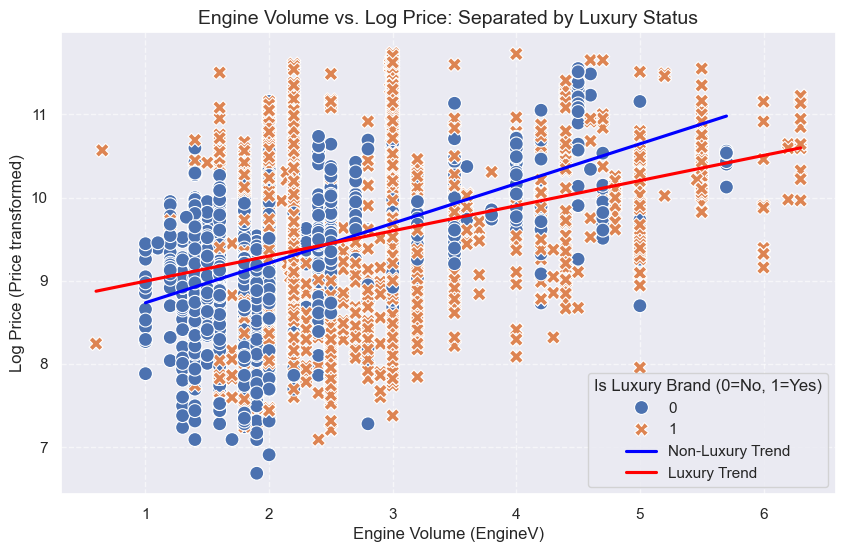

In [93]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='EngineV', y='log_price', hue='is_luxury', data=df, style='is_luxury', s=100)
sns.regplot(x='EngineV', y='log_price', data=df[df['is_luxury']==0], scatter=False, label='Non-Luxury Trend', color='blue', ci=None)
sns.regplot(x='EngineV', y='log_price', data=df[df['is_luxury']==1], scatter=False, label='Luxury Trend', color='red', ci=None)

plt.title('Engine Volume vs. Log Price: Separated by Luxury Status', fontsize=14)
plt.xlabel('Engine Volume (EngineV)', fontsize=12)
plt.ylabel('Log Price (Price transformed)', fontsize=12)
plt.legend(title='Is Luxury Brand (0=No, 1=Yes)', loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.savefig('Visuals/Interaction_Premium_Validation.png')

print("Interaction_Premium_Validation.png")
print("\nDataFrame head after feature engineering:")
print(df.head())

In [94]:

# One-Hot Encoding (OHE) for Body Type (Low-Cardinality Feature)


# OHE is used for Body Type to create clean, independent binary features.
# drop_first=True prevents the Dummy Variable Trap (multicollinearity).
df = pd.get_dummies(df, columns=['Body'], prefix='Body', drop_first=True)

print(" One-Hot Encoding Complete.")
print("Binary columns created for 'Body'.")


 One-Hot Encoding Complete.
Binary columns created for 'Body'.


In [95]:
df.columns

Index(['Brand', 'Mileage', 'EngineV', 'Engine Type', 'Registration', 'Model',
       'Car_Age', 'Mileage_per_Year', 'log_price', 'is_luxury',
       'Luxury_EngineV_Interaction', 'Body_hatch', 'Body_other', 'Body_sedan',
       'Body_vagon', 'Body_van'],
      dtype='object')

In [96]:
# 1. Select all numeric types AND the boolean dummy variables
df_numeric = df.select_dtypes(include=['number', 'bool'])

# 2. Compute correlation matrix (now including the dummies)
corr_matrix = df_numeric.corr()

# 3. Display correlation of each feature with log_price
corr_with_price = corr_matrix['log_price'].sort_values(ascending=False)
print("Correlation with Body Dummies Included:")
print(corr_with_price.head(10))
print(corr_with_price.tail(10))

Correlation with Body Dummies Included:
log_price                     1.000000
EngineV                       0.412123
Luxury_EngineV_Interaction    0.244522
is_luxury                     0.157100
Body_other                    0.037133
Body_van                     -0.126162
Body_hatch                   -0.135914
Body_sedan                   -0.136156
Body_vagon                   -0.177740
Mileage_per_Year             -0.383856
Name: log_price, dtype: float64
Luxury_EngineV_Interaction    0.244522
is_luxury                     0.157100
Body_other                    0.037133
Body_van                     -0.126162
Body_hatch                   -0.135914
Body_sedan                   -0.136156
Body_vagon                   -0.177740
Mileage_per_Year             -0.383856
Mileage                      -0.606462
Car_Age                      -0.743032
Name: log_price, dtype: float64


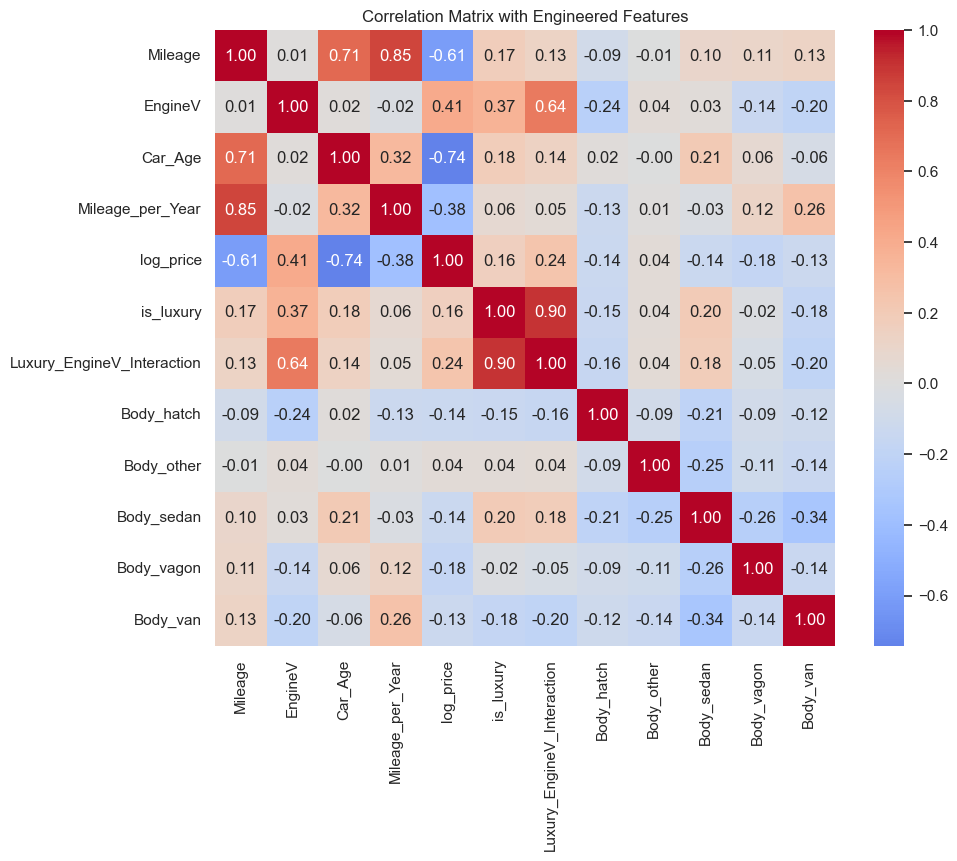

In [97]:

plt.figure(figsize=(10, 8)) # Slightly smaller, standard size
sns.heatmap(
    corr_matrix, 
    annot=True,  
    fmt='.2f',      
    cmap='coolwarm', 
    center=0
)
plt.title('Correlation Matrix with Engineered Features')
plt.savefig('Visuals/Correlation_Matrix_Final.png')
plt.show()

In [98]:
corr_with_price = corr_matrix['log_price'].sort_values(ascending=False)
print(corr_with_price)


log_price                     1.000000
EngineV                       0.412123
Luxury_EngineV_Interaction    0.244522
is_luxury                     0.157100
Body_other                    0.037133
Body_van                     -0.126162
Body_hatch                   -0.135914
Body_sedan                   -0.136156
Body_vagon                   -0.177740
Mileage_per_Year             -0.383856
Mileage                      -0.606462
Car_Age                      -0.743032
Name: log_price, dtype: float64


In [99]:
# This tells which features (like EngineV, Car_Age, Mileage) have the strongest relationships with price.

In [100]:
#for sales team it is important to convert log price into the real rice.
df['Original_Price'] = np.exp(df['log_price'])

In [101]:
df

,Brand,Mileage,EngineV,Engine Type,Registration,Model,Car_Age,Mileage_per_Year,log_price,is_luxury,Luxury_EngineV_Interaction,Body_hatch,Body_other,Body_sedan,Body_vagon,Body_van,Original_Price
0,BMW,277,2.0,Petrol,yes,320,34,8.15,8.342840,1,2.0,False,False,True,False,False,4200.0
1,Mercedes-Benz,427,2.9,Diesel,yes,Sprinter 212,26,16.42,8.974618,1,2.9,False,False,False,False,True,7900.0
2,Mercedes-Benz,358,5.0,Gas,yes,S 500,22,16.27,9.495519,1,5.0,False,False,True,False,False,13300.0
3,Audi,240,4.2,Petrol,yes,Q7,18,13.33,10.043249,1,4.2,False,False,False,False,False,23000.0
4,Toyota,120,2.0,Petrol,yes,Rav 4,14,8.57,9.814656,0,0.0,False,False,False,False,False,18300.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3811,Renault,152,1.6,Petrol,yes,Megane,18,8.44,8.824678,0,0.0,False,False,True,False,False,6800.0
3812,Volkswagen,163,2.5,Diesel,yes,T5 (Transporter),17,9.59,9.350102,0,0.0,False,False,False,False,True,11500.0
3813,Toyota,35,1.6,Petrol,yes,Corolla,11,3.18,9.792556,0,0.0,False,False,True,False,False,17900.0
3814,BMW,1,3.5,Petrol,yes,535,26,0.04,8.779557,1,3.5,False,False,True,False,False,6500.0


In [102]:
df.to_csv('Data/EDA_data.csv' ,index=False)